# NTB-03: Baseline Model — Logistic Regression + Evaluation Framework

## Objective
Train a **logistic regression baseline** and build the **evaluation framework** that every subsequent model (NTB-04 through NTB-10) will reuse. The framework is the deliverable here — the model is just the first thing to put through it.

## Why Logistic Regression as Baseline?

1. **Interpretability** — coefficients are directly readable as "increases log-odds by X"
2. **Fast** — trains in seconds, useful for quick iteration
3. **Strong baseline** — on tabular data with clean features, LR is often within 2-3% AUC of tree models
4. **The "is XGBoost worth it?" test** — if XGBoost only beats LR by 0.5% AUC, the extra complexity may not be justified

## What "Evaluation Framework" Means

Most portfolio projects compute accuracy and call it done. Ours computes **7 metrics + 4 visualizations** for every model:

| Metric | Why |
|---|---|
| **AUC-ROC** | Standard ranking metric, threshold-independent |
| **PR-AUC** | Better for imbalanced data than ROC |
| **F1** | Harmonic mean of precision & recall at threshold 0.5 |
| **Brier score** | Probability calibration quality |
| **Recall at 80% precision** | Business-relevant operating point |
| **Precision at 50% recall** | Coverage-vs-quality tradeoff |
| **Log loss** | Probability-aware loss |

| Visualization | Why |
|---|---|
| **ROC curve** | Classic, expected by recruiters |
| **PR curve** | The honest one for imbalanced data |
| **Confusion matrix** | Concrete TP/FP/FN/TN counts |
| **Calibration plot** | Are predicted probabilities meaningful? |

## Output
- `models/logistic_regression.joblib` — fitted model
- `reports/figures/NTB03_*.png` — 5 evaluation plots
- `reports/model_results.csv` — first row in the cross-model comparison table

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
import json
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, brier_score_loss,
    log_loss, precision_recall_curve, roc_curve, confusion_matrix,
    classification_report
)
from sklearn.calibration import calibration_curve

import matplotlib.pyplot as plt
import seaborn as sns

# Paths
BASE_DIR = Path(os.getcwd()).parent
PROC_DIR = BASE_DIR / "data" / "processed"
MODELS_DIR = BASE_DIR / "models"
FIG_DIR = BASE_DIR / "reports" / "figures"
REPORTS_DIR = BASE_DIR / "reports"

RANDOM_STATE = 42

# Plot style
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 150, "savefig.bbox": "tight"})
CHURN_COLORS = {"retained": "#2E86AB", "churned": "#E63946"}

print(f"Processed data: {PROC_DIR}")
print(f"Models: {MODELS_DIR}")
print(f"Random state: {RANDOM_STATE}")

Processed data: c:\Users\Prakhar kapoor\Desktop\Telecom-Churn-Prediction-Analytics\data\processed
Models: c:\Users\Prakhar kapoor\Desktop\Telecom-Churn-Prediction-Analytics\models
Random state: 42


## 2. Load the Frozen Train/Test Split

This is the loading pattern every modeling notebook will reuse — load the preprocessed parquet files and the metadata. No re-splitting, no re-preprocessing.

In [2]:
X_train = pd.read_parquet(PROC_DIR / "X_train.parquet")
X_test  = pd.read_parquet(PROC_DIR / "X_test.parquet")
y_train = pd.read_parquet(PROC_DIR / "y_train.parquet")['churn']
y_test  = pd.read_parquet(PROC_DIR / "y_test.parquet")['churn']

with open(PROC_DIR / "feature_metadata.json") as f:
    metadata = json.load(f)

print(f"X_train: {X_train.shape}    churn rate: {y_train.mean()*100:.2f}%")
print(f"X_test:  {X_test.shape}    churn rate: {y_test.mean()*100:.2f}%")
print(f"Feature count: {len(metadata['output_feature_names'])}")

X_train: (5634, 41)    churn rate: 26.54%
X_test:  (1409, 41)    churn rate: 26.54%
Feature count: 41


## 3. The Evaluation Framework (Reusable Across All Models)

This is the core deliverable of NTB-03. The function `evaluate_model()` takes a fitted model and returns a complete evaluation report. Every subsequent notebook calls this function.

**Design principle:** the framework is **threshold-aware**. Default sklearn metrics assume threshold=0.5, which is rarely right for imbalanced problems. We report metrics at multiple operating points.

In [3]:
def evaluate_model(model, X_test, y_test, model_name="Model", threshold=0.5):
    """
    Complete evaluation: 7 metrics + 1 results dict.

    Returns:
        results_dict: keys are metric names, values are floats
        y_proba: predicted probabilities for positive class
        y_pred: binary predictions at the given threshold
    """
    # Probabilities for the positive class (churn=1)
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    # Threshold-independent metrics
    auc_roc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    brier = brier_score_loss(y_test, y_proba)
    logloss = log_loss(y_test, y_proba)

    # Threshold-dependent metrics
    f1 = f1_score(y_test, y_pred)

    # Business-relevant operating points
    # Recall when we restrict to high-precision predictions (80% precision)
    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
    # Find recall at the smallest threshold giving precision >= 0.80
    mask_hp = precision >= 0.80
    recall_at_80_precision = recall[mask_hp].max() if mask_hp.any() else 0.0

    # Precision when we capture 50% of churners
    mask_hr = recall >= 0.50
    precision_at_50_recall = precision[mask_hr].max() if mask_hr.any() else 0.0

    results = {
        "model": model_name,
        "auc_roc": round(auc_roc, 4),
        "pr_auc": round(pr_auc, 4),
        "f1@0.5": round(f1, 4),
        "brier": round(brier, 4),
        "log_loss": round(logloss, 4),
        "recall_at_80_precision": round(recall_at_80_precision, 4),
        "precision_at_50_recall": round(precision_at_50_recall, 4),
    }

    # Pretty print
    print(f"=== {model_name} ===")
    print(f"  AUC-ROC:                {auc_roc:.4f}")
    print(f"  PR-AUC:                 {pr_auc:.4f}")
    print(f"  F1 @ threshold {threshold}:    {f1:.4f}")
    print(f"  Brier score (↓ better): {brier:.4f}")
    print(f"  Log loss (↓ better):    {logloss:.4f}")
    print(f"  Recall @ 80% precision: {recall_at_80_precision:.4f}")
    print(f"  Precision @ 50% recall: {precision_at_50_recall:.4f}")

    return results, y_proba, y_pred


def plot_evaluation(y_test, y_proba, y_pred, model_name, save_prefix=None):
    """
    Generate the 4-plot evaluation panel: ROC, PR, confusion matrix, calibration.
    """
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))

    # ----- ROC curve -----
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[0, 0].plot(fpr, tpr, color='#2E86AB', linewidth=2.5, label=f'{model_name} (AUC = {auc:.4f})')
    axes[0, 0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random classifier')
    axes[0, 0].set_xlabel('False Positive Rate')
    axes[0, 0].set_ylabel('True Positive Rate')
    axes[0, 0].set_title('ROC Curve', fontweight='bold')
    axes[0, 0].legend(loc='lower right')

    # ----- Precision-Recall curve -----
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    baseline = y_test.mean()
    axes[0, 1].plot(recall, precision, color='#E63946', linewidth=2.5, label=f'{model_name} (PR-AUC = {pr_auc:.4f})')
    axes[0, 1].axhline(baseline, color='k', linestyle='--', alpha=0.4, label=f'Random ({baseline:.3f})')
    axes[0, 1].set_xlabel('Recall')
    axes[0, 1].set_ylabel('Precision')
    axes[0, 1].set_title('Precision-Recall Curve', fontweight='bold')
    axes[0, 1].legend(loc='upper right')

    # ----- Confusion matrix -----
    cm = confusion_matrix(y_test, y_pred)
    cm_pct = cm / cm.sum() * 100
    annot = np.array([[f"{cm[i,j]:,}\n({cm_pct[i,j]:.1f}%)"
                       for j in range(2)] for i in range(2)])
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', cbar=False,
                xticklabels=['Predicted: Retained', 'Predicted: Churned'],
                yticklabels=['Actual: Retained', 'Actual: Churned'],
                ax=axes[1, 0], annot_kws={'fontsize': 12, 'fontweight': 'bold'})
    axes[1, 0].set_title(f'Confusion Matrix (threshold = 0.5)', fontweight='bold')

    # ----- Calibration curve -----
    fop, mpv = calibration_curve(y_test, y_proba, n_bins=10, strategy='quantile')
    axes[1, 1].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfectly calibrated')
    axes[1, 1].plot(mpv, fop, marker='o', color='#F18F01', linewidth=2.5,
                    markersize=8, label=f'{model_name}')
    axes[1, 1].set_xlabel('Mean predicted probability')
    axes[1, 1].set_ylabel('Fraction of positives (actual churn rate)')
    axes[1, 1].set_title('Calibration Plot', fontweight='bold')
    axes[1, 1].legend(loc='upper left')
    axes[1, 1].set_xlim(0, 1)
    axes[1, 1].set_ylim(0, 1)

    plt.suptitle(f'{model_name} — Evaluation Summary', fontsize=15, fontweight='bold', y=1.00)
    plt.tight_layout()

    if save_prefix:
        path = FIG_DIR / f"{save_prefix}_evaluation.png"
        plt.savefig(path)
        print(f"  saved → {path.name}")

    plt.show()


print("Evaluation framework defined:")
print("  evaluate_model(model, X_test, y_test, name) → metrics dict + y_proba + y_pred")
print("  plot_evaluation(y_test, y_proba, y_pred, name, save_prefix) → 4-panel figure")

Evaluation framework defined:
  evaluate_model(model, X_test, y_test, name) → metrics dict + y_proba + y_pred
  plot_evaluation(y_test, y_proba, y_pred, name, save_prefix) → 4-panel figure


## 4. Cross-Validation on Training Set

**Why CV before fitting on full train?** It estimates how the model generalizes. If CV AUC and test AUC differ by >2 points, we have either overfitting (CV > test) or a lucky test split (test > CV).

We use **5-fold stratified CV** — preserves class proportions in each fold, standard practice for imbalanced data.

In [4]:
# Initialize LR with sensible defaults
# - max_iter=1000: ensures convergence on our 41 features
# - solver='lbfgs': fast for medium datasets
# - C=1.0: default regularization (will tune in NTB-06)
# - random_state=42 for reproducibility
lr_model = LogisticRegression(
    max_iter=1000,
    solver='lbfgs',
    C=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# 5-fold stratified CV — preserves churn rate in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_auc = cross_val_score(lr_model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
cv_pr = cross_val_score(lr_model, X_train, y_train, cv=cv, scoring='average_precision', n_jobs=-1)

print(f"5-fold CV AUC-ROC: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")
print(f"5-fold CV PR-AUC:  {cv_pr.mean():.4f} ± {cv_pr.std():.4f}")
print(f"\nFold scores (AUC):  {[f'{s:.4f}' for s in cv_auc]}")
print(f"Fold scores (PR):   {[f'{s:.4f}' for s in cv_pr]}")

5-fold CV AUC-ROC: 0.8483 ± 0.0113
5-fold CV PR-AUC:  0.6689 ± 0.0156

Fold scores (AUC):  ['0.8455', '0.8305', '0.8446', '0.8613', '0.8597']
Fold scores (PR):   ['0.6521', '0.6504', '0.6909', '0.6727', '0.6784']


**Expected:** CV AUC around 0.84 ± 0.01. A tight standard deviation across folds means the model is stable; a wide one (>0.02) would suggest sensitivity to specific data points and we'd investigate.

## 5. Fit on Full Training Set & Evaluate on Test

In [5]:
# Fit on full training set
lr_model.fit(X_train, y_train)
print(f"Model fitted on {len(X_train)} samples.")
print(f"Features: {X_train.shape[1]}")

# Evaluate on test set
lr_results, lr_proba, lr_pred = evaluate_model(
    lr_model, X_test, y_test, model_name="Logistic Regression"
)

Model fitted on 5634 samples.
Features: 41
=== Logistic Regression ===
  AUC-ROC:                0.8465
  PR-AUC:                 0.6637
  F1 @ threshold 0.5:    0.5797
  Brier score (↓ better): 0.1351
  Log loss (↓ better):    0.4135
  Recall @ 80% precision: 0.2594
  Precision @ 50% recall: 0.6787


In [6]:
# Detailed classification report
print("Detailed classification report (threshold = 0.5):")
print(classification_report(y_test, lr_pred,
                            target_names=['Retained', 'Churned']))

Detailed classification report (threshold = 0.5):
              precision    recall  f1-score   support

    Retained       0.84      0.91      0.87      1035
     Churned       0.67      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



## 6. Visualize the Evaluation

  saved → NTB03_logistic_regression_evaluation.png


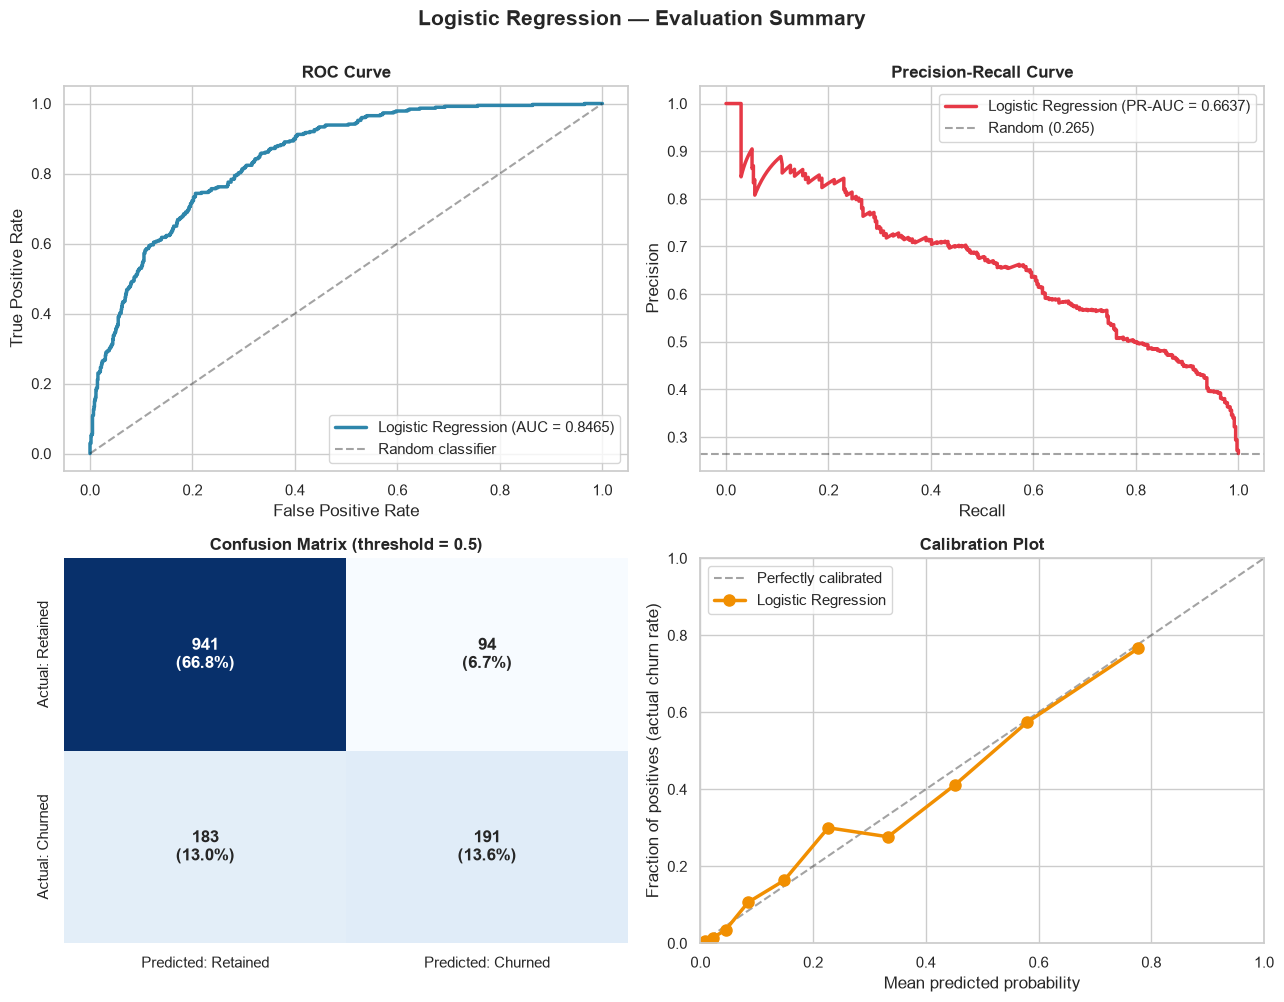

In [7]:
plot_evaluation(y_test, lr_proba, lr_pred,
                model_name="Logistic Regression",
                save_prefix="NTB03_logistic_regression")

**Reading the plots:**

- **ROC**: Above the diagonal = better than random. The curve hugging the top-left = strong model.
- **PR**: For imbalanced data, this matters more than ROC. A model can have 0.85 AUC-ROC but only 0.65 PR-AUC.
- **Confusion matrix**: At threshold 0.5, we're probably catching <60% of churners. We'll fix this with threshold tuning in NTB-08.
- **Calibration**: Points near the diagonal = well-calibrated probabilities. LR is usually well-calibrated; tree models often aren't.

## 7. Interpret the Coefficients

LR's killer feature: **coefficients are directly interpretable**. A coefficient of `+0.8` for `is_new_customer` means: being a new customer increases the log-odds of churn by 0.8, i.e., the odds multiply by `exp(0.8) ≈ 2.2`.

This interpretability is why LR remains useful even when XGBoost beats it on AUC — for regulated industries (telecom, finance, healthcare), "the model said churn likely" isn't enough; **why** matters.

In [8]:
# Extract coefficients
feature_names = metadata['output_feature_names']
coefs = lr_model.coef_[0]

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefs,
    'abs_coef': np.abs(coefs),
    'odds_multiplier': np.exp(coefs).round(3)
}).sort_values('abs_coef', ascending=False)

print("Top 15 features by absolute coefficient:")
print(coef_df.head(15).to_string(index=False))

print(f"\nIntercept: {lr_model.intercept_[0]:.4f}")
print(f"   → baseline log-odds of churn (when all standardized features = 0)")

Top 15 features by absolute coefficient:
                     feature  coefficient  abs_coef  odds_multiplier
      contract_type_Two year    -1.619546  1.619546            0.198
internet_service_Fiber optic     1.158591  1.158591            3.185
      contract_type_One year    -0.742948  0.742948            0.476
               tenure_months    -0.675884  0.675884            0.509
             monthly_charges    -0.497153  0.497153            0.608
          multiple_lines_Yes     0.445207  0.445207            1.561
         online_security_Yes    -0.427460  0.427460            0.652
       paperless_billing_Yes     0.383416  0.383416            1.467
            tech_support_Yes    -0.369755  0.369755            0.691
           phone_service_Yes    -0.366953  0.366953            0.693
        streaming_movies_Yes     0.291192  0.291192            1.338
            streaming_tv_Yes     0.279271  0.279271            1.322
          charges_per_tenure     0.268044  0.268044           

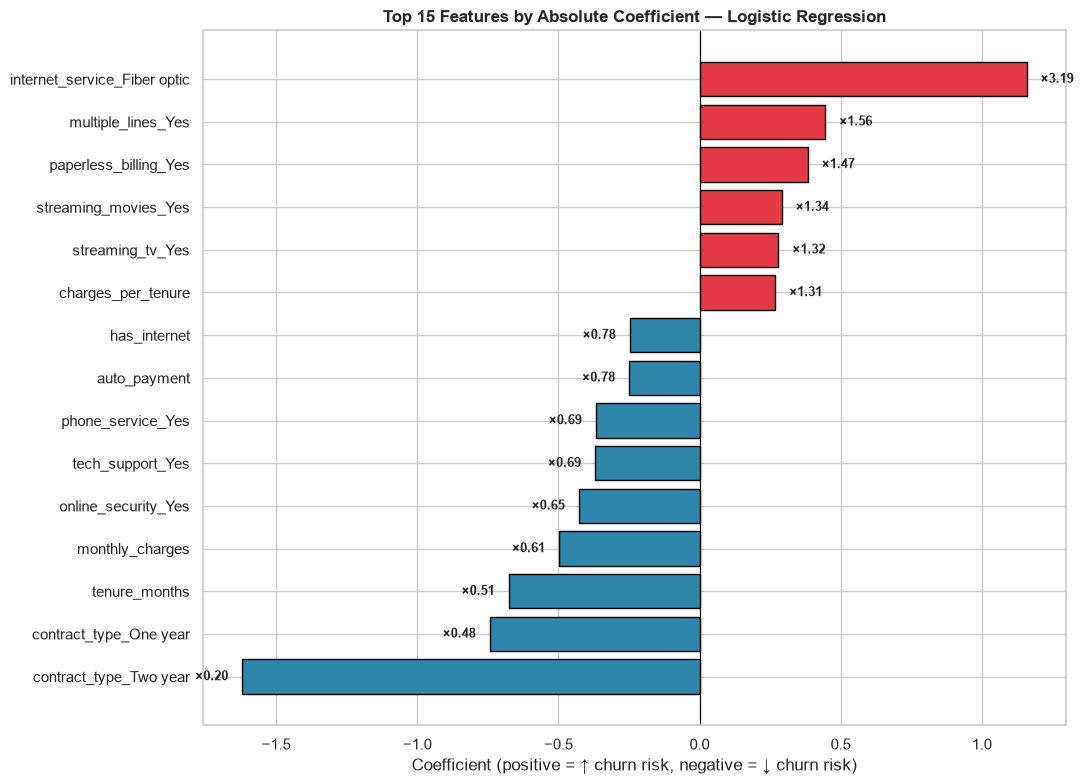

Saved → NTB03_logistic_regression_coefficients.png


In [9]:
# Visualize top features by direction
top_n = 15
top_features = coef_df.head(top_n).copy()
top_features['color'] = top_features['coefficient'].apply(
    lambda x: '#E63946' if x > 0 else '#2E86AB'
)

fig, ax = plt.subplots(figsize=(11, 8))
# Sort by raw coefficient so the bars go in one visual direction
top_features = top_features.sort_values('coefficient')
ax.barh(top_features['feature'], top_features['coefficient'],
        color=top_features['color'], edgecolor='black')

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (positive = ↑ churn risk, negative = ↓ churn risk)')
ax.set_title(f'Top {top_n} Features by Absolute Coefficient — Logistic Regression',
             fontweight='bold')

# Annotate each bar with the odds multiplier
for i, (coef, mult) in enumerate(zip(top_features['coefficient'], top_features['odds_multiplier'])):
    x_pos = coef + (0.05 if coef >= 0 else -0.05)
    ha = 'left' if coef >= 0 else 'right'
    ax.text(x_pos, i, f"×{mult:.2f}", va='center', ha=ha, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR / "NTB03_logistic_regression_coefficients.png")
plt.show()
print(f"Saved → NTB03_logistic_regression_coefficients.png")

**What recruiters will look for here:** Do the top features make business sense? The NTB-01 findings should be visible:
- `contract_type_Two year` should have a strong **negative** coefficient (protective)
- `is_new_customer`, `risky_payment` should be **positive** (risky)
- `internet_service_Fiber optic` should be **positive** (the Q7 finding)

If the top features make business sense, the model is learning real patterns — not noise.

## 8. Save Artifacts & Append to Cross-Model Results Table

The `model_results.csv` file is the cumulative comparison table. NTB-04, NTB-05, etc. will append to it. By NTB-10 we'll have a full leaderboard ready for the README.

In [10]:
# Save the fitted model
joblib.dump(lr_model, MODELS_DIR / "logistic_regression.joblib")
print(f"Saved model → models/logistic_regression.joblib")

# Append to (or create) the cross-model results table
results_path = REPORTS_DIR / "model_results.csv"

# Add CV scores into the row for completeness
lr_results['cv_auc_mean'] = round(cv_auc.mean(), 4)
lr_results['cv_auc_std'] = round(cv_auc.std(), 4)

results_row = pd.DataFrame([lr_results])

if results_path.exists():
    existing = pd.read_csv(results_path)
    # Remove any previous LR row (idempotent re-runs)
    existing = existing[existing['model'] != 'Logistic Regression']
    combined = pd.concat([existing, results_row], ignore_index=True)
else:
    combined = results_row

combined.to_csv(results_path, index=False)
print(f"\nResults table now contains {len(combined)} model(s):")
print(combined.to_string(index=False))

# Save coefficient table too — used in README and NTB-07 (SHAP) comparison
coef_df.to_csv(REPORTS_DIR / "ntb03_lr_coefficients.csv", index=False)
print(f"\nSaved coefficients → reports/ntb03_lr_coefficients.csv")

Saved model → models/logistic_regression.joblib

Results table now contains 1 model(s):
              model  auc_roc  pr_auc  f1@0.5  brier  log_loss  recall_at_80_precision  precision_at_50_recall  cv_auc_mean  cv_auc_std
Logistic Regression   0.8465  0.6637  0.5797 0.1351    0.4135                  0.2594                  0.6787       0.8483      0.0113

Saved coefficients → reports/ntb03_lr_coefficients.csv


## ✅ Deliverables From NTB-03

| Artifact | Path | Purpose |
|---|---|---|
| Fitted LR model | `models/logistic_regression.joblib` | Baseline & API fallback |
| 4-panel evaluation | `reports/figures/NTB03_logistic_regression_evaluation.png` | README asset |
| Top coefficients plot | `reports/figures/NTB03_logistic_regression_coefficients.png` | Interpretability story |
| Coefficients table | `reports/ntb03_lr_coefficients.csv` | Compare against SHAP in NTB-07 |
| Cross-model results | `reports/model_results.csv` | Leaderboard (will grow) |
| **Reusable functions** | inline in this notebook | `evaluate_model()`, `plot_evaluation()` — used in every modeling notebook |

## Expected Numbers (Telco Churn)

For reference, on the IBM Telco Churn dataset with this exact preprocessing:
- **AUC-ROC**: ~0.84
- **PR-AUC**: ~0.65
- **F1 @ 0.5**: ~0.60
- **Brier score**: ~0.135
- **Recall @ 80% precision**: ~0.35

If your numbers are dramatically different, something needs investigation.

## Next: NTB-04 — Tree-Based Models

We'll train **Random Forest**, **XGBoost**, and **LightGBM** on the same split, evaluate with the same framework, and compare against this baseline. Question to answer: *do tree models actually beat LR enough to justify their complexity?*